In [25]:
import pyarrow
import pandas as pd
import sqlite3
import numpy
import geopandas
import geopy
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import xgboost
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import tabulate

In [26]:
df= pd.read_parquet("ceny_mieszkan_v1.parquet")

### cena za m2 a powierzchnia

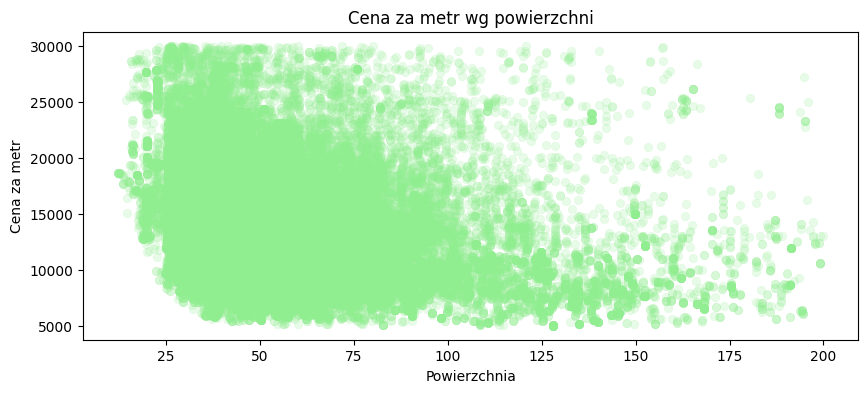

In [27]:
plt.figure(figsize=(10,4))
sns.scatterplot(
    data= df,
    x= "area",
    y="price_m2",

    alpha=0.2,
    edgecolor=None,
    facecolor="lightgreen",
)

plt.title("Cena za metr wg powierzchni")
plt.xlabel("Powierzchnia")
plt.ylabel("Cena za metr")
plt.show()

Kropki nakładają się na siebie, jakieś zależności widać, ale nie jest to czytelne.

Proponuję policzyć średnią cenę za metr kwadratowy mieszkania. Ale że mieszkania są różnej wielkości (np. 45m2, 45.1m2, 45.2m2) to zaokrąglimy ich powierzchnię do wartości całkowitych. Policzymy też ile jest tych ofert.

In [28]:
df["area_int"] = df["area"].astype(int)
df.groupby('area_int').mean("price_m2")

,id,area,price,lng,lat,floor,floors,balcony,loggia,terrace,garden,price_m2,is_service,is_commercial,is_detached
area_int,,,,,,,,,,,,,,,
12,11795.909091,12.538182,2.336364e+05,17.036446,51.082674,1.727273,1.000000,3.417273,0.0,0.000000,1.902727,18634.232900,0.0,0.0,0.000000
13,42598.000000,13.586667,2.433333e+05,17.036446,51.082674,3.500000,1.000000,4.186667,0.0,0.000000,0.000000,17909.763632,0.0,0.0,0.000000
14,37967.500000,14.570000,2.666667e+05,18.597110,52.198407,2.500000,1.000000,1.260000,0.0,0.000000,1.795000,18329.399649,0.0,0.0,0.000000
15,59452.000000,15.440000,3.329412e+05,19.002172,51.378169,1.647059,1.000000,2.101176,0.0,7.703529,1.257059,21514.550710,0.0,0.0,0.000000
16,50199.916667,16.338125,3.322917e+05,19.233092,51.520652,2.916667,1.000000,2.332708,0.0,0.000000,0.222708,20351.953285,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,56560.857143,195.245714,4.381429e+06,20.209035,50.130874,-0.142857,1.285714,9.442857,0.0,47.271429,77.427143,22442.170242,0.0,0.0,0.714286
196,105.000000,196.540000,2.660000e+06,19.941177,50.038315,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,13534.140633,1.0,1.0,0.000000
197,62287.571429,197.588571,2.528571e+06,18.887715,54.167401,-1.000000,3.000000,0.000000,0.0,0.000000,0.000000,12797.917124,0.0,0.0,1.000000


In [29]:
df_plot = df \
    .groupby("area_int", as_index=False) \
    .aggregate(
        price_m2_mean= ("price_m2", "mean"),
        price_m2_count= ("price_m2", "count")
    )